# Trading Strategy — Sections 8.1–8.2

Fixed-risk and half-Kelly grid search, best-config selection, equity curves and monthly P&L
for the 2025 Kalshi WNBA backtest.

**Outputs:**

| File | Purpose |
|---|---|
| `trade_fixed_risk_best_config_table.csv` | Best fixed-$1 config per model |
| `trade_half_kelly_best_config_table.csv` | Best half-Kelly config per model |
| `trade_half_kelly_equity_curves.png` | Half-Kelly equity (Elo vs Full Model) |
| `trade_fixed_risk_threshold_grid.csv` | Full fixed-risk grid |
| `trade_half_kelly_threshold_grid.csv` | Full half-Kelly grid |
| `trade_monthly_performance.png` | Monthly P&L by model |
| `trade_monthly_performance_table.csv` | Monthly P&L numbers |

In [ ]:
import sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13, 'figure.dpi': 120})

ANALYSIS_DIR = Path('../..').resolve() / 'src' / 'srwnba' / 'analysis'
if str(ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_DIR))

from outputs import save_fig, save_table
from walkforward import fit_holdout_models
from markets import build_kalshi_trading_index
from trading import (
    collect_entries, run_fixed_risk, run_kelly_ideal, add_trade_returns,
    equity_by_payout, BANKROLL_INIT,
)

MODELS = [('elo', 'p_elo'), ('full_model', 'p_full_model')]
MODEL_LABELS = {'elo': 'Elo', 'full_model': 'Full Model'}
MODEL_COLORS = {'elo': '#3498db', 'full_model': '#e74c3c'}
ENTRY_WINDOWS = ['half_life', 'two_thirds_life']
EDGE_MINS  = [0.05, 0.10, 0.15]
NORM_MINS  = [0.0, 0.10, 0.20, 0.25]

In [2]:
# Train holdout predictions and build market index
preds_df, _ = fit_holdout_models(
    {'xgb_with_elo': {'type': 'xgb', 'use_bm': True}, 'elo': {'type': 'elo'}},
    holdout_year=2025,
)
model_w = preds_df[preds_df['model'] == 'xgb_with_elo'][['game_id','pred_prob']].rename(columns={'pred_prob':'p_full_model'})
elo_w   = preds_df[preds_df['model'] == 'elo'][['game_id','pred_prob']].rename(columns={'pred_prob':'p_elo'})

# Need full signals row including game_ts/team ids for trading index
from final_model import load_year, LABEL_COL  # type: ignore
test_df = load_year(2025).dropna(subset=[LABEL_COL, 'base_margin'])[
    ['game_id','game_ts','game_date','home_team_id','away_team_id', LABEL_COL]
].copy()
test_df['game_ts']   = pd.to_datetime(test_df['game_ts'], utc=True)
test_df['game_date'] = pd.to_datetime(test_df['game_date'])
signals = test_df.merge(model_w, on='game_id').merge(elo_w, on='game_id')

idx = build_kalshi_trading_index(signals)
ticker_info, pretip, wt = idx['ticker_info'], idx['pretip'], idx['wt']
game_dt_map = signals.set_index('game_id')['game_date'].to_dict()
game_ts_map = signals.set_index('game_id')['game_ts'].to_dict()
print(f'Tickers: {len(ticker_info)}  |  with candles: {len(pretip)}  |  window trades: {len(wt):,}')

  xgb_with_elo             best_round=88
Tickers: 296  |  with candles: 296  |  window trades: 34,062


## Grid search
Sweep `(model, entry_window, edge_min, norm_min)` × `{fixed, half_kelly}`.
Saves the full grid for the appendix tables.

In [3]:
rows = []
for model_name, model_col in MODELS:
    for ew in ENTRY_WINDOWS:
        for em in EDGE_MINS:
            for nm in NORM_MINS:
                entries = collect_entries(ticker_info, pretip, model_col, em, nm, ew)
                leads = [(game_ts_map[e['game_id']] - e['entry_ts']).total_seconds()/3600
                         for e in entries if e['game_id'] in game_ts_map]
                med_lead = round(float(np.median(leads)), 1) if leads else float('nan')

                for sizing, runner in [
                    ('fixed',      lambda e: run_fixed_risk(e, risk_per_trade=1.0, bankroll_init=BANKROLL_INIT)),
                    ('half_kelly', lambda e: run_kelly_ideal(e, 0.5, BANKROLL_INIT)),
                ]:
                    trades = runner(entries)
                    if not trades:
                        rows.append({
                            'model': model_name, 'entry_window': ew, 'edge_min': em, 'norm_min': nm,
                            'sizing': sizing, 'n_trades': 0, 'hit_rate': 0, 'mean_edge': 0,
                            'total_pnl': 0, 'roi': 0, 'final_bankroll': BANKROLL_INIT,
                            'total_return': 0, 'max_drawdown': 0, 'mean_log_ret': 0,
                            'std_log_ret': 0, 'median_lead_h': med_lead,
                        })
                        continue
                    tdf = pd.DataFrame(trades)
                    n = len(tdf)
                    base = {
                        'model': model_name, 'entry_window': ew,
                        'edge_min': em, 'norm_min': nm, 'sizing': sizing,
                        'n_trades': n, 'hit_rate': round(tdf['won'].mean(), 4),
                        'mean_edge': round(tdf['edge'].mean(), 4),
                        'total_fees': round(tdf['fee'].sum(), 2),
                        'total_pnl': round(tdf['pnl'].sum(), 2),
                        'median_lead_h': med_lead,
                    }
                    if sizing == 'fixed':
                        base['roi'] = round(tdf['pnl'].sum() / n, 4)
                        for k in ('final_bankroll','total_return','max_drawdown',
                                  'mean_kelly_f','mean_wager','mean_log_ret','std_log_ret'):
                            base[k] = float('nan')
                    else:
                        tdf = add_trade_returns(tdf)
                        fb = tdf['bankroll'].iloc[-1]
                        base.update({
                            'roi': float('nan'),
                            'final_bankroll': round(fb, 2),
                            'total_return': round((fb - BANKROLL_INIT) / BANKROLL_INIT, 4),
                            'max_drawdown': round((tdf['bankroll'].cummax() - tdf['bankroll']).max(), 2),
                            'mean_kelly_f': round(tdf['kelly_f'].mean(), 4),
                            'mean_wager': round(tdf['wager'].mean(), 2),
                            'mean_log_ret': round(tdf['log_ret'].mean(), 6),
                            'std_log_ret': round(tdf['log_ret'].std(), 6),
                        })
                    rows.append(base)

grid = pd.DataFrame(rows)
save_table(grid[grid['sizing']=='fixed'].copy(),      'trade_fixed_risk_threshold_grid')
save_table(grid[grid['sizing']=='half_kelly'].copy(), 'trade_half_kelly_threshold_grid')
print(f'Grid: {len(grid)} configs ({grid["n_trades"].gt(0).sum()} with trades)')

  saved: outputs\trade_fixed_risk_threshold_grid.csv
  saved: outputs\trade_half_kelly_threshold_grid.csv
Grid: 96 configs (96 with trades)


---
## §8.1 — Best fixed-risk config (per model)
**Table:** `trade_fixed_risk_best_config_table`.

In [4]:
fixed = grid[(grid['sizing'] == 'fixed') & (grid['entry_window'] == 'half_life') & (grid['n_trades'] > 0)]
best_fixed = (
    fixed.sort_values('roi', ascending=False)
         .groupby('model', as_index=False)
         .head(1)
         .reset_index(drop=True)
         [['model','edge_min','norm_min','n_trades','hit_rate','mean_edge',
           'total_fees','total_pnl','roi','median_lead_h']]
)
save_table(best_fixed, 'trade_fixed_risk_best_config_table')
best_fixed

  saved: outputs\trade_fixed_risk_best_config_table.csv


,model,edge_min,norm_min,n_trades,hit_rate,mean_edge,total_fees,total_pnl,roi,median_lead_h
0,full_model,0.15,0.25,59,0.5254,0.1919,2.82,21.32,0.3614,13.5
1,elo,0.15,0.25,68,0.3971,0.1872,3.60,18.88,0.2777,13.6


---
## §8.2 — Best half-Kelly config (per model)
**Table:** `trade_half_kelly_best_config_table`.

In [5]:
hk = grid[(grid['sizing'] == 'half_kelly') & (grid['entry_window'] == 'half_life') & (grid['n_trades'] > 0)]
best_hk = (
    hk.sort_values('total_return', ascending=False)
      .groupby('model', as_index=False)
      .head(1)
      .reset_index(drop=True)
      [['model','edge_min','norm_min','n_trades','hit_rate','mean_kelly_f','mean_wager',
        'total_fees','final_bankroll','total_return','max_drawdown',
        'mean_log_ret','std_log_ret','median_lead_h']]
)
save_table(best_hk, 'trade_half_kelly_best_config_table')
best_hk

  saved: outputs\trade_half_kelly_best_config_table.csv


,model,edge_min,norm_min,n_trades,hit_rate,mean_kelly_f,mean_wager,total_fees,final_bankroll,total_return,max_drawdown,mean_log_ret,std_log_ret,median_lead_h
0,full_model,0.05,0.25,134,0.4030,0.2176,109.56,566.31,1161.79,10.6179,2706.17,0.018303,0.173766,13.5
1,elo,0.05,0.25,155,0.3419,0.1890,53.08,366.31,516.97,4.1697,1096.10,0.010599,0.173190,14.8


---
## §8.2 — Half-Kelly equity curves
**Figure:** `trade_half_kelly_equity_curves`.

In [ ]:
best_trades = {}
for model_name, model_col in MODELS:
    best = best_hk[best_hk['model'] == model_name].iloc[0]
    entries = collect_entries(ticker_info, pretip, model_col,
                              best['edge_min'], best['norm_min'], 'half_life')
    trades = run_kelly_ideal(entries, 0.5, BANKROLL_INIT)
    tdf = add_trade_returns(pd.DataFrame(trades))
    tdf['game_date'] = pd.to_datetime(tdf['game_id'].map(game_dt_map))
    best_trades[model_name] = (tdf, best)

# Equity curves are sorted by settlement (payout) time so they're monotonic in
# the date axis. Engine bankrolls compound in entry-timestamp order, which on
# multi-game days produces visual loop-backs that look like a bug.
fig, ax = plt.subplots(figsize=(10, 5))
for model_name, (tdf, best) in best_trades.items():
    eq = equity_by_payout(tdf, bankroll_init=BANKROLL_INIT, ts_col='game_ts')
    ret = (eq['display_bankroll'].iloc[-1] - BANKROLL_INIT) / BANKROLL_INIT
    ax.step(eq['game_ts'], eq['display_bankroll'], where='post',
            color=MODEL_COLORS[model_name], linewidth=1.8,
            label=f'{MODEL_LABELS[model_name]} ({ret:.0%} return)')
ax.axhline(BANKROLL_INIT, color='gray', linestyle=':', alpha=0.5, label='Starting bankroll')
ax.set_xlabel('Settlement date'); ax.set_ylabel('Bankroll ($)')
ax.set_title('Half-Kelly Equity Curves for Elo and Full Model Strategies', fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b'))
plt.tight_layout()
save_fig(fig, 'trade_half_kelly_equity_curves')
plt.show()

---
## §8 Appendix — Monthly performance
**Figure:** `trade_monthly_performance`. **Table:** `trade_monthly_performance_table`.

  saved: outputs\trade_monthly_performance.png


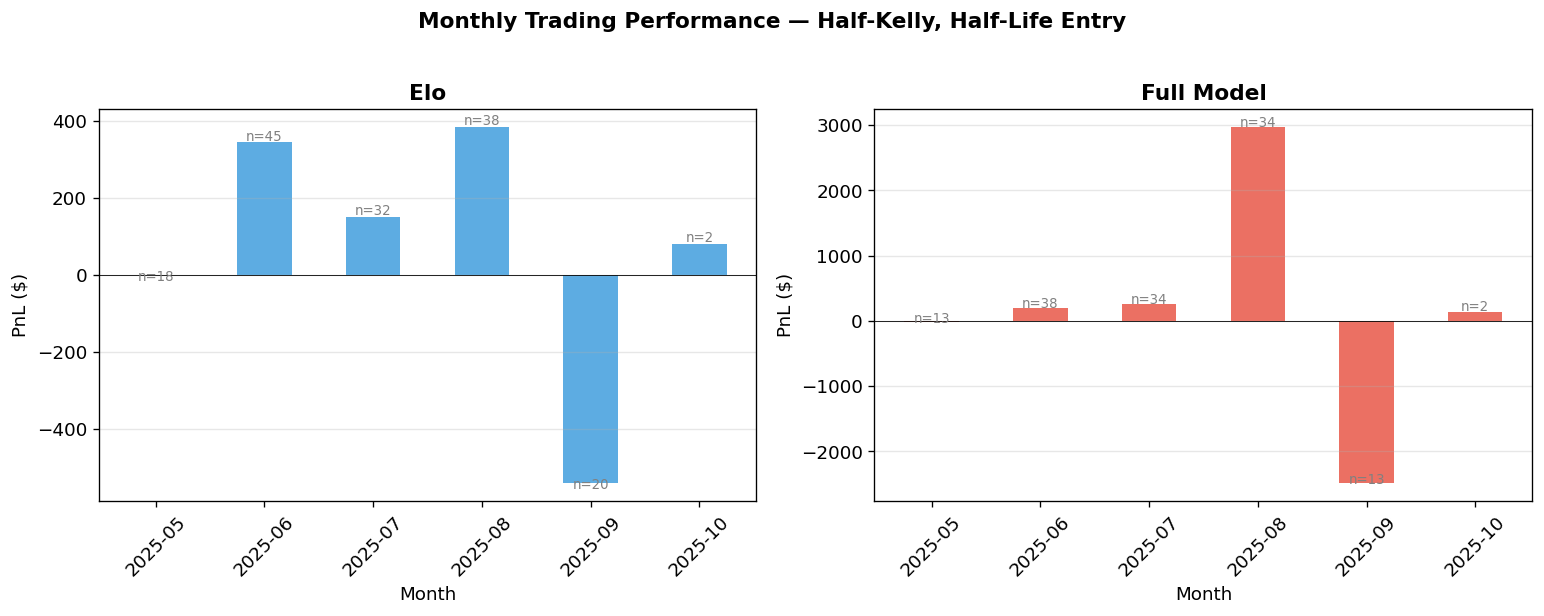

  saved: outputs\trade_monthly_performance_table.csv


,month,n_trades,pnl,hit_rate,model,month_str
0,2025-05,18,-1.278744,0.222222,elo,2025-05
1,2025-06,45,344.328396,0.377778,elo,2025-06
2,2025-07,32,151.216055,0.312500,elo,2025-07
3,2025-08,38,383.491943,0.421053,elo,2025-08
4,2025-09,20,-541.228508,0.250000,elo,2025-09
5,2025-10,2,80.443043,0.500000,elo,2025-10
6,2025-05,13,-10.483258,0.230769,full_model,2025-05
7,2025-06,38,196.007674,0.394737,full_model,2025-06
8,2025-07,34,251.629562,0.382353,full_model,2025-07
9,2025-08,34,2966.991423,0.588235,full_model,2025-08


In [7]:
monthly_rows = []
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (model_name, _) in zip(axes, MODELS):
    tdf, best = best_trades[model_name]
    tdf = tdf.copy()
    tdf['month'] = tdf['game_date'].dt.to_period('M')
    monthly = (
        tdf.groupby('month').agg(n_trades=('pnl','count'), pnl=('pnl','sum'),
                                 hit_rate=('won','mean'))
        .reset_index()
    )
    monthly['model'] = model_name
    monthly_rows.append(monthly)

    monthly['month_str'] = monthly['month'].astype(str)
    bars = ax.bar(monthly['month_str'], monthly['pnl'], width=0.5,
                  color=MODEL_COLORS[model_name], alpha=0.8)
    for bar, n in zip(bars, monthly['n_trades']):
        y = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, y + (5 if y >= 0 else -15),
                f'n={int(n)}', ha='center', fontsize=8, color='gray')
    ax.set_title(MODEL_LABELS[model_name], fontweight='bold')
    ax.set_xlabel('Month'); ax.set_ylabel('PnL ($)')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.grid(axis='y', alpha=0.3); ax.tick_params(axis='x', rotation=45)

plt.suptitle('Monthly Trading Performance — Half-Kelly, Half-Life Entry',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, 'trade_monthly_performance')
plt.show()

monthly_tbl = pd.concat(monthly_rows, ignore_index=True)
monthly_tbl['month'] = monthly_tbl['month'].astype(str)
save_table(monthly_tbl, 'trade_monthly_performance_table')
monthly_tbl